In [ ]:
import polars as pl

base = "/fs/ess/PAS2159/HughesLab2/ANITA_DATA/parquet_for_fitting/"
df_training = pl.read_parquet( base + "processed_training_data.parquet")
df_test = pl.read_parquet( base + "processed_testing_data.parquet")

print("training:", df_training.shape)
print("testing:", df_test.shape)

## this first cell opens a parquet file for both the training and test data
## each row is pulled into memory as a polars dataframe
## the shape is printed merely as confirmation
## from what I understand, the point is that the machine learning model learns
## from one set of events (our training data) and then is tested on a different
## set of events (test data) that it has not seen before
## we do not want the test data influence our training data at all, those are seperate

training: (41959, 43)
testing: (10678, 43)


In [ ]:
import numpy as np

def get_X(df):
    X = df["processed_waveforms"].to_numpy()
    if X.ndim ==1:
        X = np.stack(df["processed_waveforms"].to_list())
    return X

X_training = get_X(df_training)
X_test = get_X(df_test)

y_training = df_training[["mctheta", "mcphi"]].to_numpy()
y_test = df_test[["mctheta", "mcphi"]].to_numpy()

print("X_training", X_training.shape, "y_training", y_training.shape)
print("X_test", X_test.shape, "y_test", y_test.shape)

## I got lazy when writing out process_waveforms (which i know is awful documentation)
## but I will say it here, X = processed_waveforms, get_X pulls the processed
## waveforms column out of the dataframe as a numpy array, ideally we should be seeing
## a shape of (n_events, 9600)
## a couple times it was coming back as a 1D array instead, so np.stack was used to bypass that
## for the y values, the [[]] chooses two columns and converts them to a 2D array
## there is one row per event and two columns (column 0=theta, column 1=phi)

X_training (41959, 9600) y_training (41959, 2)
X_test (10678, 9600) y_test (10678, 2)


In [7]:
from sklearn.ensemble import RandomForestRegressor

## for now I want to do something small, nothing that will take too long
n_sub = 5000
rf = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42, verbose=2)
rf.fit(X_training[:n_sub], y_training[:n_sub])
print("done training")

building tree 1 of 50
building tree 2 of 50
building tree 3 of 50
building tree 4 of 50


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50


[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:  8.2min


building tree 38 of 50
building tree 39 of 50
building tree 40 of 50
building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50
done training


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 11.9min finished


In [8]:
pred = rf.predict(X_test)

theta_err = pred[:, 0] - y_test[:,0]
phi_err = (pred[:,1] - y_test[:, 1] +180) % 360 -180

print(f"theta error: mean = {theta_err.mean():7.3f}  std={theta_err.std():7.3f}")
print (f"phi error: mean = {phi_err.mean():7.3f}  std={phi_err.std():7.3f}")

theta error: mean =   0.074  std=  1.401
phi error: mean =   0.240  std= 27.500


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:    0.1s finished


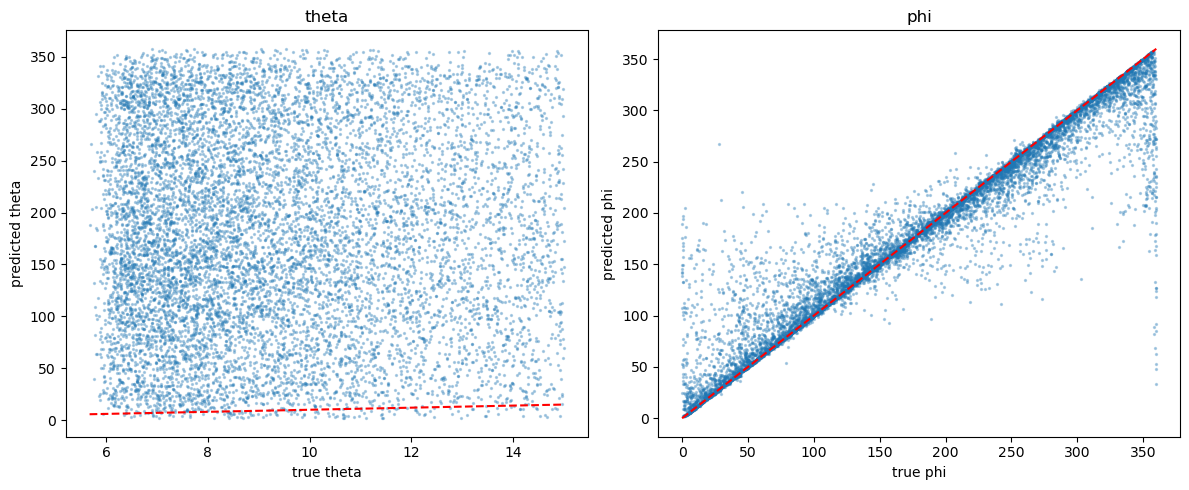

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax, i, name in [(axes[0], 0, "theta"), (axes[1], 1, "phi")]:
    ax.scatter(y_test[:, i], pred[:,1], s=2, alpha=0.3)
    lo, hi = y_test[:, i].min(), y_test[:, i].max()
    ax.plot([lo, hi], [lo, hi], "r--")
    ax.set_xlabel(f"true {name}")
    ax.set_ylabel(f"predicted {name}")
    ax.set_title(name)
plt.tight_layout()
plt.show()